Dataset:
[1.  1.2 1.5 1.8 2.  7.  7.2 7.5 7.8 8. ]

EXPECTATION-MAXIMIZATION RESULTS

Data Point	Cluster
1.0 		Cluster 1
1.2 		Cluster 1
1.5 		Cluster 1
1.8 		Cluster 1
2.0 		Cluster 1
7.0 		Cluster 2
7.2 		Cluster 2
7.5 		Cluster 2
7.8 		Cluster 2
8.0 		Cluster 2

Gaussian Means:
[1.5 7.5]

Gaussian Variances:
[0.136001 0.136001]

Mixing Weights:
[0.5 0.5]

Log-Likelihood:
-1.1145

Cluster Probabilities:
Data: 1.0 -> [1. 0.]
Data: 1.2 -> [1. 0.]
Data: 1.5 -> [1. 0.]
Data: 1.8 -> [1. 0.]
Data: 2.0 -> [1. 0.]
Data: 7.0 -> [0. 1.]
Data: 7.2 -> [0. 1.]
Data: 7.5 -> [0. 1.]
Data: 7.8 -> [0. 1.]
Data: 8.0 -> [0. 1.]


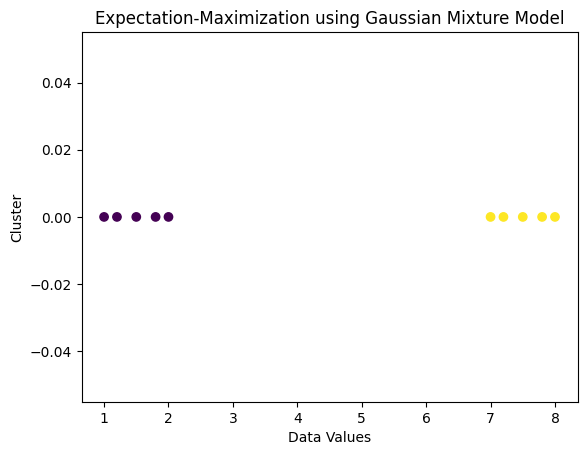

In [ ]:
# Experiment 10: Expectation-Maximization (EM) Algorithm
# Aim: Implement the Expectation-Maximization algorithm
#      using a Gaussian Mixture Model.

import numpy as np
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture


# ---------------------------------------------------------
# STEP 1: Create a simple dataset
# ---------------------------------------------------------

X = np.array([
    1.0, 1.2, 1.5, 1.8, 2.0,
    7.0, 7.2, 7.5, 7.8, 8.0
]).reshape(-1, 1)

print("Dataset:")
print(X.flatten())


# ---------------------------------------------------------
# STEP 2: Create the Gaussian Mixture Model
# ---------------------------------------------------------

# Number of Gaussian clusters
n_components = 2

gmm = GaussianMixture(
    n_components=n_components,
    random_state=42
)


# ---------------------------------------------------------
# STEP 3: Train the model using EM algorithm
# ---------------------------------------------------------

gmm.fit(X)


# ---------------------------------------------------------
# STEP 4: Predict cluster for each data point
# ---------------------------------------------------------

labels = gmm.predict(X)


# ---------------------------------------------------------
# STEP 5: Display the results
# ---------------------------------------------------------

print("\n" + "=" * 50)
print("EXPECTATION-MAXIMIZATION RESULTS")
print("=" * 50)

print("\nData Point\tCluster")

for value, label in zip(X.flatten(), labels):
    print(
        round(value, 2),
        "\t\tCluster",
        label + 1
    )


# ---------------------------------------------------------
# STEP 6: Display Gaussian parameters
# ---------------------------------------------------------

print("\nGaussian Means:")
print(gmm.means_.flatten())

print("\nGaussian Variances:")
print(gmm.covariances_.flatten())

print("\nMixing Weights:")
print(gmm.weights_)


# ---------------------------------------------------------
# STEP 7: Display log likelihood
# ---------------------------------------------------------

print("\nLog-Likelihood:")
print(round(gmm.lower_bound_, 4))


# ---------------------------------------------------------
# STEP 8: Display cluster probabilities
# ---------------------------------------------------------

probabilities = gmm.predict_proba(X)

print("\nCluster Probabilities:")

for i, value in enumerate(X.flatten()):
    print(
        "Data:",
        round(value, 2),
        "->",
        np.round(probabilities[i], 4)
    )


# ---------------------------------------------------------
# STEP 9: Plot the clusters
# ---------------------------------------------------------

plt.scatter(
    X.flatten(),
    np.zeros(len(X)),
    c=labels
)

plt.xlabel("Data Values")
plt.ylabel("Cluster")
plt.title("Expectation-Maximization using Gaussian Mixture Model")
plt.show()